## Corporate clustering prototype
This notebook analyses the `champions_group_data.csv` dataset. The goal is to build a prototype system that helps users derive actionable insights from company-level data by analysing firmographic, operational, and organizational attributes.

We will follow these steps:
1.  **Data Checking & Cleaning**: Load the data, check for missing values, and remove duplicates.
2.  **Exploratory Data Analysis (EDA)**: Investigate the features, their distributions, and their relationships with each other.
3.  **Preprocessing & Modeling**: Prepare the data for unsupervised modelling, using K-Means and Hierarchical Clustering to find natural groups.
4. **Cluster Interpretation**: Using Radar Charts to explain why a group exists.
5. **Building the tool**: Building a tool easily accesible for users to gain insights from big data.

## 1. Importing necessary package and getting data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors 

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import silhouette_score

import pickle
import warnings
warnings.filterwarnings('ignore') 

sns.set(style="whitegrid")

In [2]:
data = pd.read_csv('../data/champions_group_data.csv')

## 2. Data Checking & Cleaning

Before our data analysis, data checking and cleaning is a crucial step. We have to ensure that the data processed is cleaned such as no missing values and no duplicates.

### 2.1 Initial Check of Raw Dataset

In [3]:
# Check initial shape of dataset
data.shape

(8559, 72)

After loading the data, the `.shape` command tells us we have 8559 rows (company sites) and 72 columns (variables).

### 2.2 Check for duplicates

In [4]:
# Check for duplicates
data.duplicated().sum()

np.int64(0)

We found 0 duplicated rows and hence every entry in our dataset is unique.

## 3. Exploratory Data Analysis

### 3.1 Univariate Analysis

To explore the variables on its own and examine its distribution and analyse its patterns. We will be doing this for selected variables. 

#### 3.1.1 Categorical Variables

**Country**

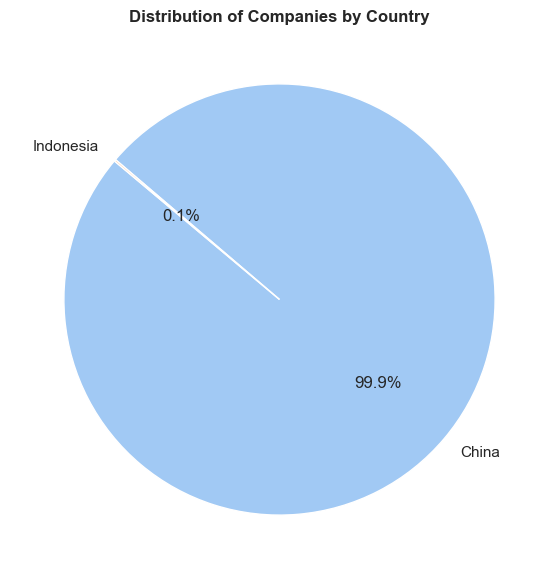

In [5]:
data['Country'] = data['Country'].str.strip().str.title()
country_counts = data['Country'].value_counts()

colors = sns.color_palette('pastel')[0:len(country_counts)]

plt.figure(figsize=(7, 7))
plt.pie(country_counts, 
        labels=country_counts.index, 
        colors=colors,               
        autopct='%.1f%%',           
        startangle=140,
        wedgeprops={'edgecolor': 'white'}) 

plt.title('Distribution of Companies by Country', fontweight='bold')
plt.show()

As mentioned above, we will still keep the `Country` variable even if it's skewed as it still provides valuable input for buyers who are interested in companies in Indonesia.

**Entity Type & Ownership Type**

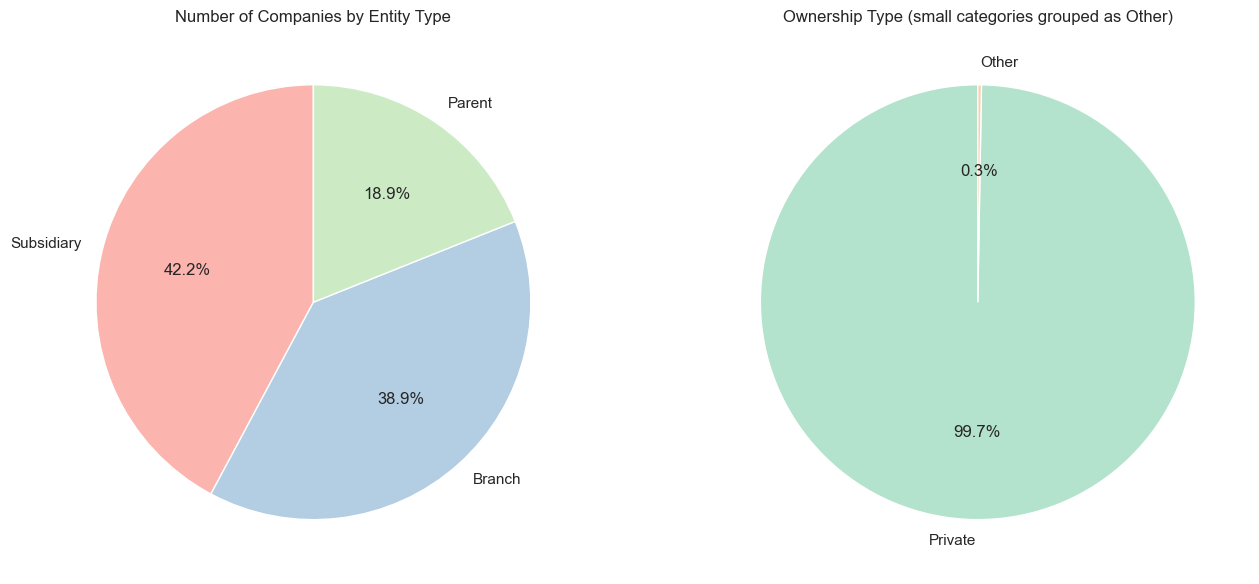

In [6]:
# Count data
entity_counts = data['Entity Type'].value_counts()
ownership_counts = data['Ownership Type'].value_counts()

# Group smaller categories into "Other" 
threshold_percent = 1  # anything <1% will be grouped
ownership_percent = ownership_counts / ownership_counts.sum() * 100

# Keep large categories
ownership_grouped = ownership_percent[ownership_percent >= threshold_percent].copy()
# Add "Other" category
ownership_grouped['Other'] = 100 - ownership_grouped.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie for Entity Type
axes[0].pie(entity_counts, labels=entity_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel1.colors)
axes[0].set_title('Number of Companies by Entity Type')

# Pie for Ownership Type (using "Other")
axes[1].pie(ownership_grouped, labels=ownership_grouped.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel2.colors)
axes[1].set_title('Ownership Type (small categories grouped as Other)')

plt.tight_layout()
plt.show()


Since the remaining categories under `Ownership Type` represent very small proportions of the dataset, they were combined into an "Other" category. This grouping reduces sparsity and ensures that these rare categories do not disproportionately affect clustering results.

**Industry Codes**

We use visualizations to determine the most suitable industry code. Industry codes classify companies into sectors, enabling meaningful grouping for analysis and benchmarking. We select the code with the highest data coverage to ensure consistency and completeness in our segmentation.

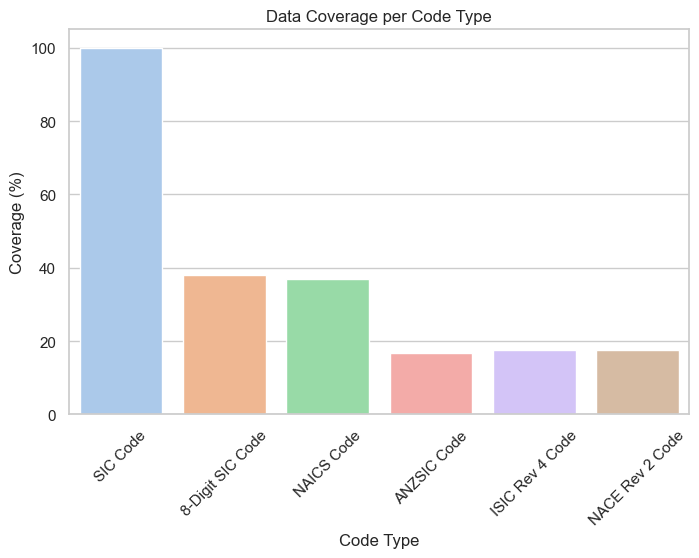

In [7]:
code_columns = [
    'SIC Code',
    '8-Digit SIC Code',
    'NAICS Code',
    'ANZSIC Code',
    'ISIC Rev 4 Code',
    'NACE Rev 2 Code'
]

coverage = (1 - data[code_columns].isna().mean()) * 100  # % of non-missing
plt.figure(figsize=(8,5))
sns.barplot(x=coverage.index, y=coverage.values, palette='pastel')
plt.ylabel('Coverage (%)')
plt.xlabel('Code Type')
plt.title('Data Coverage per Code Type')
plt.xticks(rotation=45)
plt.show()


Since `SIC Code` is 100% populated in the dataset, we will use this instead of the other codes.

**Legal Status**

In [8]:
legal_status_counts = data['Legal Status'].value_counts().sort_index()

# Combine into a table
legal_status_table = pd.DataFrame({
    'Count': legal_status_counts
})

legal_status_table

,Count
Legal Status,
0.0,873
3.0,7453
8.0,85
12.0,30
13.0,27
50.0,7
100.0,1
101.0,54
120.0,27


The `Legal Status` variable indicates a potential classification of firms. However, without supporting documentation to define the categories, the variable cannot be meaningfully interpreted and is therefore excluded.

**Electronics**

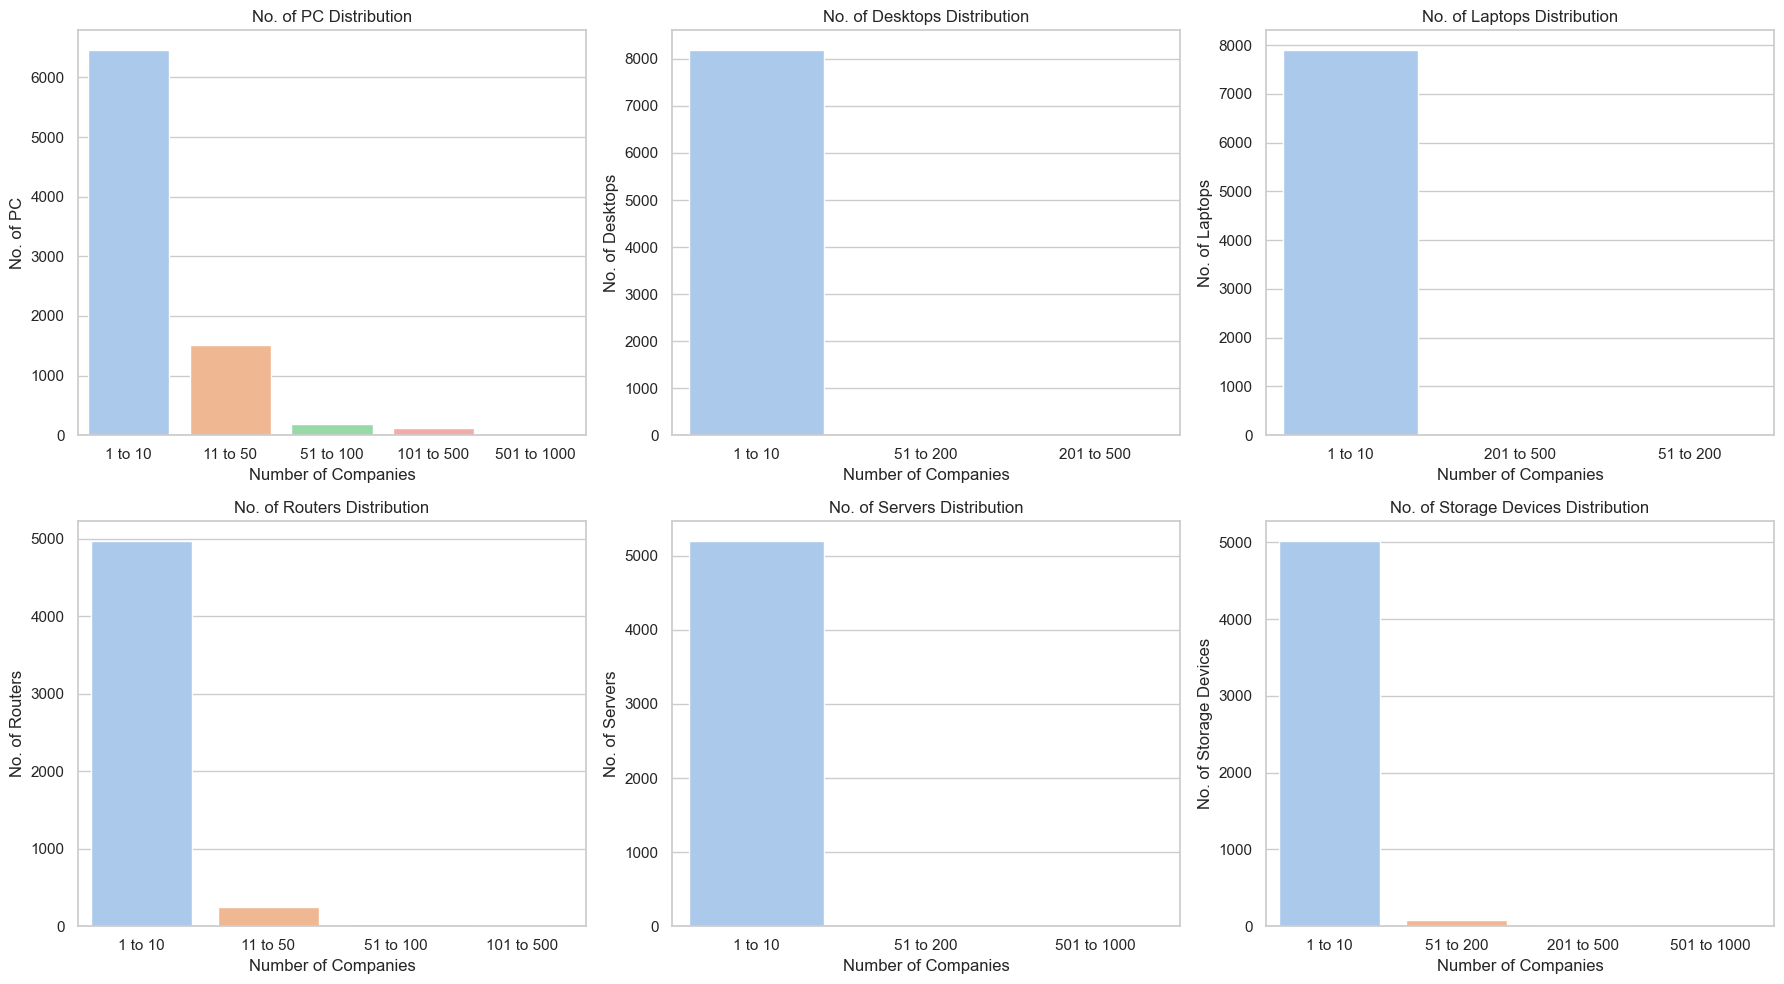

In [9]:
hardware_cols = [
    'No. of PC', 'No. of Desktops', 'No. of Laptops',
    'No. of Routers', 'No. of Servers', 'No. of Storage Devices'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, hardware_cols):
    sns.countplot(
        x=col,               # horizontal bars, easier to read ranges
        data=data,
        order=data[col].value_counts().index,  
        ax=ax, 
        palette='pastel'
    )
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel('Number of Companies')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

#### 3.1.2 Numerical Variables

**Year Found**

In [10]:

bins = list(range(1900, 2040, 10))
labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins)-1)]

data['Year_Range'] = pd.cut(
    data['Year Found'],
    bins=bins,
    labels=labels,
    right=False
)

bin_counts = (
    data['Year_Range']
    .value_counts(dropna=False)
    .sort_index()
)

bin_percent = bin_counts / bin_counts.sum() * 100

year_table = pd.DataFrame({
    "Count": bin_counts,
    "Percentage": bin_percent.round(2)
})

year_table



,Count,Percentage
Year_Range,,
1900-1909,1,0.01
1910-1919,0,0.00
1920-1929,0,0.00
1930-1939,0,0.00
1940-1949,2,0.02
1950-1959,23,0.27
1960-1969,7,0.08
1970-1979,10,0.12
1980-1989,126,1.47


**Corporate Family Members, Employees Single Site, Employees Total**

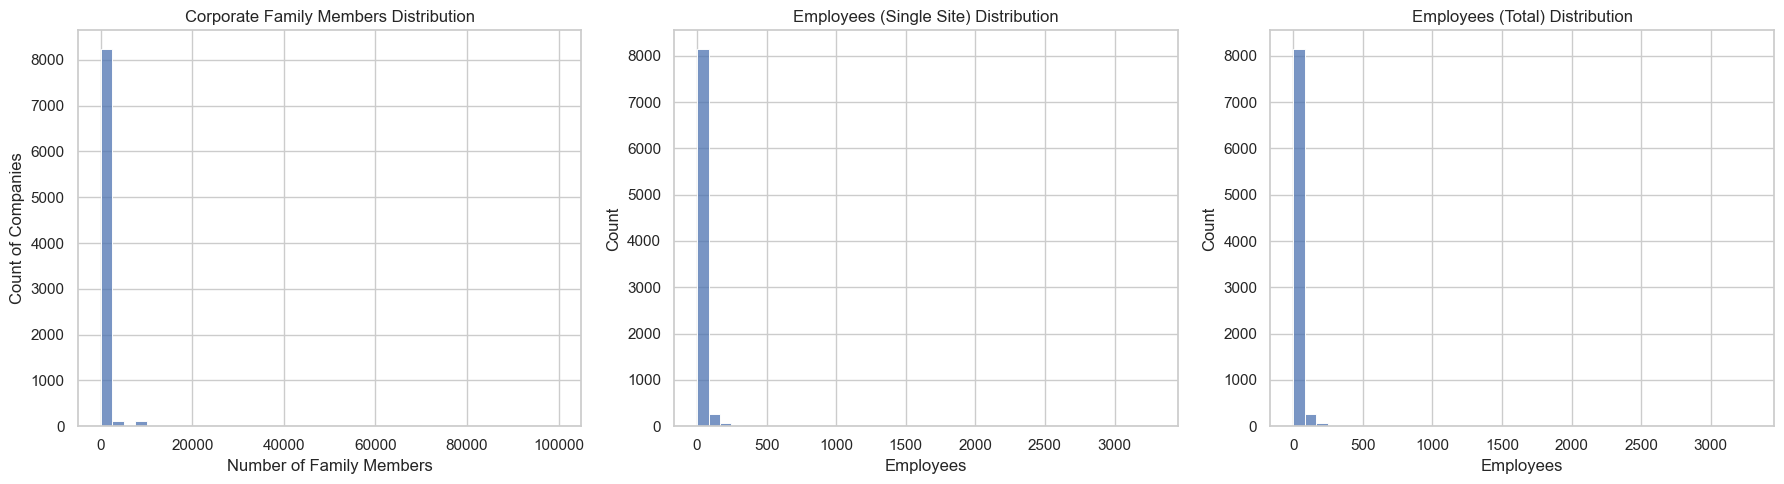

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(
    data['Corporate Family Members'].dropna(),
    bins=40,
    ax=axes[0], 
    palette='pastel'
)
axes[0].set_title('Corporate Family Members Distribution')
axes[0].set_xlabel('Number of Family Members')
axes[0].set_ylabel('Count of Companies')

sns.histplot(
    data['Employees Single Site'].dropna(),
    bins=40,
    ax=axes[1], 
    palette='pastel'
)
axes[1].set_title('Employees (Single Site) Distribution')
axes[1].set_xlabel('Employees')

sns.histplot(
    data['Employees Total'].dropna(),
    bins=40,
    ax=axes[2],
    palette='pastel'
)
axes[2].set_title('Employees (Total) Distribution')
axes[2].set_xlabel('Employees')

plt.tight_layout()
plt.show()

Due to their high right-skewness, the variables `Corporate Family Members`, `Employees Single Site`, and `Employees Total` should be scaled to mitigate the effect of extreme values and ensure comparability across features.

### 3.2 Bivariate Analysis

This explores relationships between 2 variables. We will explore variables that are likely to be related to each other.  

#### 3.2.1 IT Spend & IT Budget

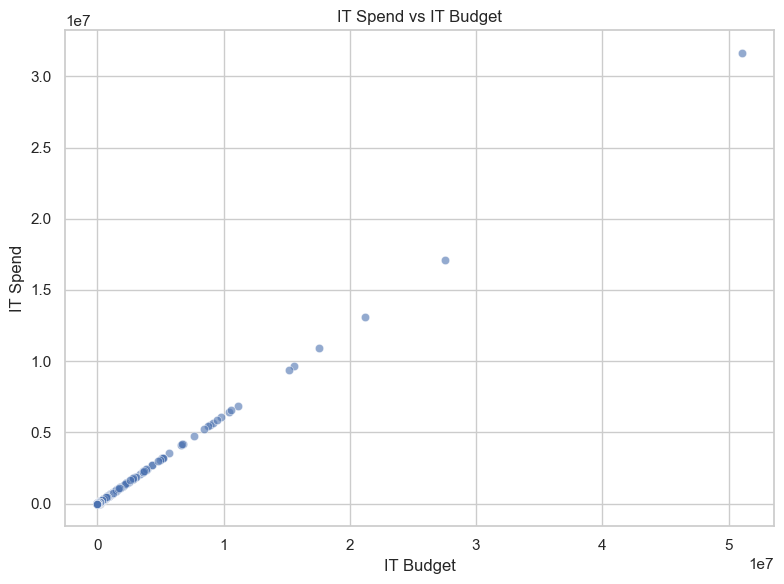

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=data,
    x="IT Budget",
    y="IT spend",
    alpha=0.6
)

plt.title("IT Spend vs IT Budget")
plt.xlabel("IT Budget")
plt.ylabel("IT Spend")
plt.tight_layout()
plt.show()


The near-diagonal pattern indicates that IT spend increases proportionally with IT budget, suggesting that both variables capture the same underlying scale of IT investment and are therefore largely redundant. 

#### 3.2.2 Market Value Vs Revenue

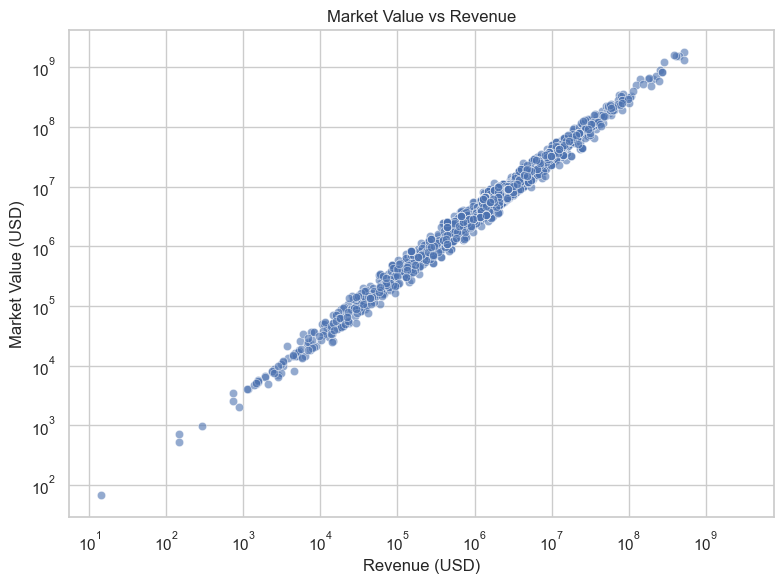

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=data,
    x="Revenue (USD)",
    y="Market Value (USD)",
    alpha=0.6
)

# Log scale is strongly recommended
plt.xscale("log")
plt.yscale("log")

plt.title("Market Value vs Revenue")
plt.xlabel("Revenue (USD)")
plt.ylabel("Market Value (USD)")
plt.tight_layout()
plt.show()


A logarithmic scale was used because Market Value and Revenue span several orders of magnitude. Applying a log transformation reduces the influence of extreme values, improves interpretability across firms of different sizes, and makes proportional (multiplicative) relationships easier to observe.

Similar to IT Budget and IT Spend, the relationship between Market Value and Revenue is approximately linear.

#### 3.2.3 Entity Type Vs Employees Single Site

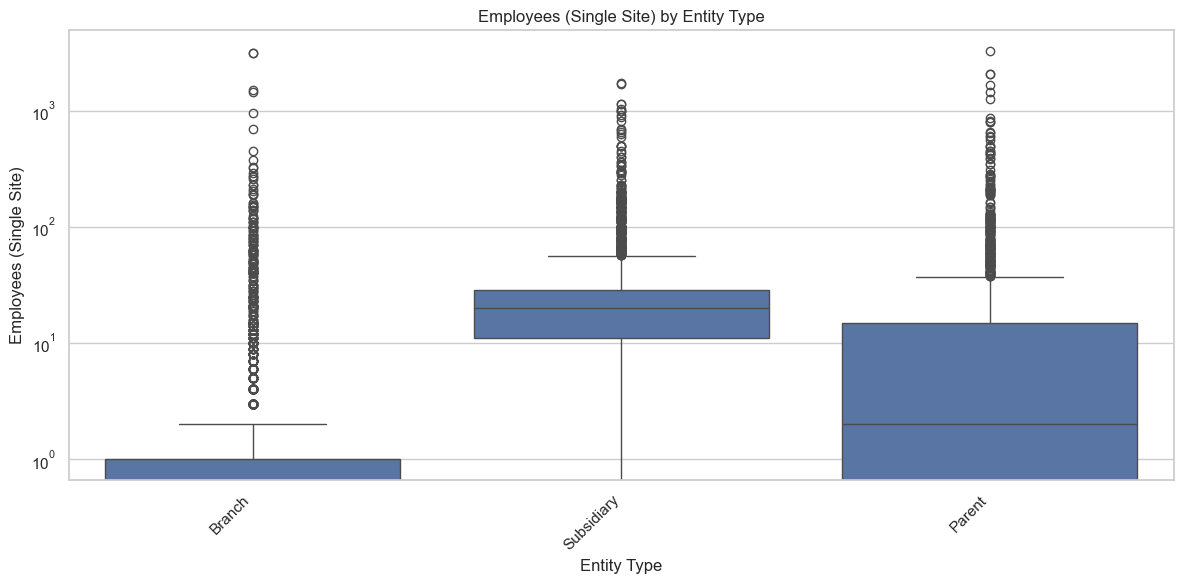

In [14]:
#boxplot on log scale 

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=data,
    x="Entity Type",
    y="Employees Single Site"
)

plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.title("Employees (Single Site) by Entity Type")
plt.ylabel("Employees (Single Site)")
plt.xlabel("Entity Type")
plt.tight_layout()
plt.show()


The boxplot reveals systematic differences in typical site size across entity types, with subsidiaries generally employing more staff per site, while branches are predominantly small but exhibit a long tail of large outliers. This indicates that Employees (Single Site) contains meaningful segmentation signal but is highly right-skewed and heterogeneous.

For clustering purposes, we therefore retain Employees (Single Site) as a feature but apply a logarithmic transformation to reduce the influence of extreme values and ensure that relative differences in site size, rather than absolute counts, drive distance calculations. Entity Type is retained as contextual information rather than a primary size proxy, as substantial overlap exists across categories.

### 3.3 Multivariate Analysis

#### 3.3.1 Spearson Correlation Matrix

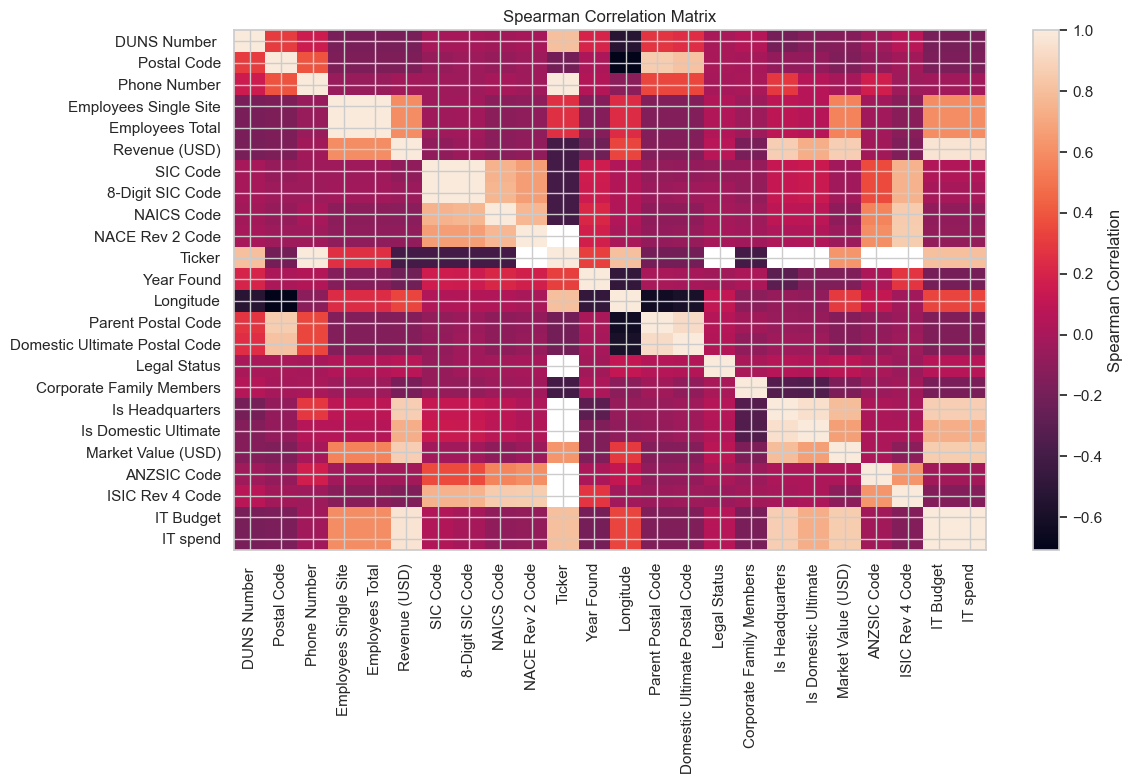

In [15]:
# keep only numeric features
numeric_df = data.select_dtypes(include="number")

spearman_corr = numeric_df.corr(method="spearman")

plt.figure(figsize=(12, 8))
plt.imshow(spearman_corr, aspect="auto")
plt.colorbar(label="Spearman Correlation")
plt.xticks(range(len(spearman_corr.columns)), spearman_corr.columns, rotation=90)
plt.yticks(range(len(spearman_corr.columns)), spearman_corr.columns)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()


The Spearman correlation matrix corroborates the bivariate analysis by showing strong monotonic correlations among scale-related variables such as revenue, market value, and IT expenditure. This supports the feature reduction and ratio-based transformations applied prior to clustering.

## 4. Feature Engineering
Feature engineering is applied to ensure meaningful clustering by removing redundant variables, creating ratio-based features, applying scale and log transformations to address skewness and magnitude differences, handling missing values appropriately, and standardizing features so that no single variable disproportionately influences distance calculations.

### 3.1 Reducing Dimensionality

Since there are 72 columns, we will be dropping some columns. 

In [16]:
def audit_data_quality(df):
    summary_data = []
    
    for col in df.columns:
        missing_pct = df[col].isnull().mean() * 100
        
        unique_count = df[col].nunique()
        
        value_counts_norm = df[col].value_counts(normalize=True, dropna=True)
        if not value_counts_norm.empty:
            top_val = value_counts_norm.index[0]
            dominance_pct = value_counts_norm.iloc[0] * 100
        else:
            top_val = "Empty"
            dominance_pct = 100.0
            
        summary_data.append({
            'Column': col,
            'Missing (%)': round(missing_pct, 2),
            'Unique Values': unique_count,
            'Top Value': str(top_val)[:30],  
            'Dominance (%)': round(dominance_pct, 2),
            'Type': df[col].dtype
        })
    
    quality_df = pd.DataFrame(summary_data)

    useless_cols = quality_df[quality_df['Dominance (%)'] > 97]['Column'].tolist()
    
    high_missing_cols = quality_df[
        (quality_df['Missing (%)'] > 70)
    ]['Column'].tolist()
    
    return quality_df, list(set(useless_cols + high_missing_cols))

quality_report, suggested_drops = audit_data_quality(data)

print("Columns with > 97% Dominance:")
print(quality_report[quality_report['Dominance (%)'] > 97].sort_values(by='Dominance (%)', ascending=False))

print("\nColumns with > 70% Missing Values:")
missing_series = quality_report.set_index('Column')['Missing (%)']
print(missing_series[missing_series > 70].sort_values(ascending=False))

print(f"\nSuggested drops ({len(suggested_drops)} columns)")
print(suggested_drops)

Columns with > 97% Dominance:
                              Column  Missing (%)  Unique Values  \
10                            Region         0.00              1   
49          Registration Number Type        99.91              1   
51  Company Status (Active/Inactive)         0.00              1   
58              Manufacturing Status        96.95              1   
59                   Fiscal Year End         0.01              1   
8                            Country         0.00              2   
70                    No. of Servers        39.13              3   
68                    No. of Laptops         7.47              3   
12                    Ownership Type        12.64              5   
67                   No. of Desktops         3.98              3   
34             Parent Country/Region         0.00              9   
41      Global Ultimate Country Name         0.00             14   
71            No. of Storage Devices        40.11              4   

                 

We will proceed with dropping `Region`, `Company Status`, and `Fiscal Year End`. These features exhibit near-zero variance (almost 100% identical values), meaning they offer no discriminatory power for our analysis. 

As `SIC code` is used as the standard industry classification, alternative industry codes are excluded. We also drop attributes that do not contribute to clustering or LLM-based analysis, including address-related fields and detailed information on related companies, retaining only their name and basic location information.

Additionally, we will remove columns with >70% missing data. Given the high sparsity, these features lack critical information, and statistical imputation would likely introduce significant noise rather than recover meaningful signals.

However, despite statistical skew or missingness, we will explicitly retain high-value commercial indicators. These includes the Country, Parent Country/Region, Ownership Type columns require more analysis since they may be useful for a data buyer who is interested in companies located in other countries apart from the majority which is China or a company belonging to public sector etc.

Furthermore, IT Infrastructure columns such as the No. of Desktops, No. of Servers may be a proxy for Digital Maturity. Hence, even if sparse, the presence of this data indicates a tech-forward company, which is a key selling point for data buyers. Thus, we will not remove them as well.

In [17]:
suggested_drops.extend(['Address Line 1', 'State Or Province Abbreviation', 'Postal Code', '8-Digit SIC Code', '8-Digit SIC Description', 
                        'NAICS Code','NAICS Description', 'Parent Street Address', 'Parent State/Province Abbreviation', 'Parent Postal Code', 
                        'Global Ultimate Street Address', 'Ultimate State/Province Abbreviation', 'Global Ultimate Postal Code',
                        'Domestic Ultimate Street Address', 'Domestic Ultimate State Abbreviation', 'Domestic Ultimate Postal Code', 'Registration Number',
                        'Legal Status'
                       ])

cols_to_drop = set(suggested_drops) - {'Country', 'Parent Country/Region', 'Ownership Type', 'No. of Desktops', 'No. of Laptops', 'No. of Servers', 'No. of Storage Devices'}
cols_to_drop = list(cols_to_drop)
print(f"\nFinal columns to drop ({len(cols_to_drop)} columns):")
print(cols_to_drop)


Final columns to drop (38 columns):
['Domestic Ultimate Postal Code', 'Lattitude', 'Parent State/Province Abbreviation', 'Domestic Ultimate State Abbreviation', 'Longitude', 'Ticker', 'Website', '8-Digit SIC Code', 'ANZSIC Code', 'Is Headquarters', 'Global Ultimate Country Name', 'Address Line 1', 'Legal Status', '8-Digit SIC Description', 'Phone Number', 'Region', 'Registration Number Type', 'Company Status (Active/Inactive)', 'Franchise Status', 'Postal Code', 'ISIC Rev 4 Code', 'ANZSIC Description', 'Manufacturing Status', 'Domestic Ultimate Street Address', 'NACE Rev 2 Description', 'Is Domestic Ultimate', 'Global Ultimate Street Address', 'Ultimate State/Province Abbreviation', 'NACE Rev 2 Code', 'Parent Postal Code', 'NAICS Code', 'NAICS Description', 'Fiscal Year End', 'ISIC Rev 4 Description', 'State Or Province Abbreviation', 'Parent Street Address', 'Global Ultimate Postal Code', 'Registration Number']


In [18]:
dropped_data = data.drop(columns=cols_to_drop)

print(f"\nFinal list of columns to keep ({len(dropped_data.columns)} columns):")
for col in dropped_data.columns:
    print(f"- {col}")



Final list of columns to keep (35 columns):
- DUNS Number 
- Company Sites
- City
- State
- Country
- Entity Type
- Ownership Type
- Employees Single Site
- Employees Total
- Revenue (USD)
- SIC Code
- SIC Description
- Year Found
- Parent Company
- Parents City
- Parent State/Province
- Parent Country/Region
- Global Ultimate Company
- Global Ultimate City Name
- Global Ultimate State/Province
- Domestic Ultimate Company
- Domestic Ultimate City Name
- Domestic Ultimate State/Province Name
- Company Description
- Corporate Family Members
- Market Value (USD)
- IT Budget
- IT spend
- No. of PC
- No. of Desktops
- No. of Laptops
- No. of Routers
- No. of Servers
- No. of Storage Devices
- Year_Range


#### 3.1.2 PCA (Principal Component Analysis)

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# similarly, keep only numeric features
numeric_df_pca = dropped_data.select_dtypes(include="number")

# PCA also requires us to remove NaNs, we do so only for EDA
numeric_df_pca = numeric_df_pca.dropna()

# scale
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df_pca)
pca = PCA()
pca_data = pca.fit_transform(scaled_data)

explained_variance = pd.DataFrame({
    "Principal Component": range(1, len(pca.explained_variance_ratio_) + 1),
    "Explained Variance Ratio": pca.explained_variance_ratio_.cumsum()
})

print(explained_variance)


   Principal Component  Explained Variance Ratio
0                    1                  0.280790
1                    2                  0.474426
2                    3                  0.589846
3                    4                  0.691697
4                    5                  0.788591
5                    6                  0.866373
6                    7                  0.940173
7                    8                  0.999999
8                    9                  1.000000
9                   10                  1.000000


PCA was used to assess the underlying dimensional structure of the data by transforming correlated variables into a smaller set of uncorrelated components that capture maximum variance. In this dataset, variance is distributed across multiple components, with approximately 5–7 principal components required to explain most of the variability. This reinforces the  bivariate analyses, which showed strong linear and monotonic relationships among scale-related features. Together, these results confirm feature redundancy and support dimensionality reduction and feature consolidation prior to clustering.

### 3.2 Transforming Features

#### 3.2.1 SIC Codes
SIC (Standard Industrial Classification) codes categorize firms by industry in a hierarchical manner. Using the first two digits captures broad industry sectors while reducing sparsity and noise from overly granular classifications, making the categories more suitable for exploratory analysis and cluster interpretation.

In [20]:
# Extract first two digits of SIC code
dropped_data["SIC_2digit"] = (
    dropped_data["SIC Code"]
    .astype(str)
    .str.extract(r"(\d{2})")
)

# Concatenate unique descriptions per 2-digit SIC
sic_2digit_desc = (
    dropped_data
    .dropna(subset=["SIC_2digit", "SIC Description"])
    .groupby("SIC_2digit")["SIC Description"]
    .apply(lambda x: ", ".join(sorted(set(x))))
    .reset_index(name="SIC_2digit_Description")
)

# Merge back to original dataframe
dropped_data = dropped_data.merge(
    sic_2digit_desc,
    on="SIC_2digit",
    how="left"
)

In [21]:
unique_sic_2digit = dropped_data["SIC_2digit"].dropna().unique()
unique_sic_2digit


array(['50', '56', '20', '19', '65', '80', '12', '59', '73', '34', '54',
       '75', '41', '52', '58', '27', '55', '87', '17', '79', '42', '36',
       '89', '28', '47', '15', '62', '86', '51', '99', '82', '32', '76',
       '63', '91', '35', '48', '33', '49', '30', '83', '72', '57', '70',
       '96', '37', '16', '61', '67', '53', '39', '23', '26', '92', '38',
       '81', '11', '88', '60', '64', '78', '44', '29', '22', '84', '13',
       '95', '25', '10', '24', '45', '18', '85', '14', '21', '31', '40'],
      dtype=object)

#### 3.2.2 Market Value - Revenue Ratio
As seen in previous EDA, Market Value and Revenue is approximately linear. Hence,we will drop Market Value (USD) and keep Revenue since revenue is a better approximation of its business activity , not influenced by stock market speculations. The revenue is then subsequently log-transformed to reduce skewness and prevent extreme values from disproportionately influencing clustering results.

In [22]:
#drop market value
dropped_data = dropped_data.drop(columns=["Market Value (USD)"])

#apply log transformation
dropped_data["revenue_log"] = np.log1p(dropped_data['Revenue (USD)'])

#scaling 

scaler = StandardScaler()

dropped_data["revenue_log_scaled"] = scaler.fit_transform(
    dropped_data[["revenue_log"]]
)


#### 3.2.3 IT Spend - IT Budget Ratio
Similarly, IT spend increases proportionally with IT budget. To avoid over-representing this scale effect in clustering, we will drop IT budget and keep IT spend since IT spend is an actualised operational investment instead of just intent. 

In [23]:
#drop IT Budget 
dropped_data = dropped_data.drop(columns=["IT Budget"])

#apply log transformation to IT spend
dropped_data["IT spend_log"] = np.log1p(dropped_data['IT spend'])

#scaling
dropped_data["IT spend_log_scaled"] = scaler.fit_transform(
    dropped_data[["IT spend_log"]]
)


#### 3.2.4 Total Devices
All device-related variables were combined into a single aggregated feature to capture overall IT footprint. Categorical device ranges were first converted into numerical values using midpoints to obtain approximate counts. Aggregation was performed only when sufficient information was available to reduce partial reporting bias, and a missingness indicator was added to preserve information about incomplete reporting. The resulting feature was log-transformed to reduce skewness and prevent large firms from dominating distance-based clustering.

In [24]:
device_cols = [
    "No. of PC",
    "No. of Desktops",
    "No. of Laptops",
    "No. of Routers",
    "No. of Servers",
    "No. of Storage Devices"
]

# Convert to numerical values using midpoints
bin_map = {
    "1 to 10": 5,
    "11 to 50": 30,
    "51 to 100": 75,
    "101 to 500": 300,
    "501 to 1000": 750
}

# Mapping
for col in device_cols:
    dropped_data[col] = dropped_data[col].map(bin_map)



In [25]:
effective_employees = dropped_data['Employees Single Site'].clip(lower=1)

bins = pd.qcut(
    dropped_data['Employees Single Site'],
    q=4,
    duplicates='drop'
)

dropped_data['employee_size_bin'] = bins.cat.rename_categories(
    ['small', 'medium', 'large', 'xlarge'][:bins.cat.categories.size]
)

# 1. create device-per-employee ratios
for col in device_cols:
    dropped_data[f'{col}_ratio'] = dropped_data[col] / effective_employees

# 2. impute ratios with fallback strategy
for col in device_cols:
    ratio_col = f'{col}_ratio'

    # sic+size level
    level1 = dropped_data.groupby(
        ['SIC_2digit', 'employee_size_bin']
    )[ratio_col].transform('median')

    # only sic
    level2 = dropped_data.groupby(
        'SIC_2digit'
    )[ratio_col].transform('median')

    # global 
    global_median = dropped_data[ratio_col].median()

    final_ratio = level1.fillna(level2).fillna(global_median)

    # convert
    dropped_data[col] = dropped_data[col].fillna(
        final_ratio * effective_employees
    )

# 3. remove temp ratio columns
dropped_data.drop(
    columns=[f'{col}_ratio' for col in device_cols],
    inplace=True
)


In [26]:
# Aggregate device count
# If more than 2 devices are missing, total is missing
dropped_data["total_devices"] = dropped_data[device_cols].sum(
    axis=1,
    min_count=4
)

# Missingness indicator - if more than 2 devices are unrecorded
dropped_data["total_devices_missing"] = (
    dropped_data["total_devices"].isna().astype(int)
)

# Log-transform total devices (safe for skewed distributions)
dropped_data["log_total_devices"] = np.log1p(dropped_data["total_devices"])

# Drop original device columns and unlogged total
dropped_data = dropped_data.drop(
    columns=device_cols + ["total_devices"]
)

missing_counts = dropped_data.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
print(missing_counts)

City                                      514
State                                     515
Ownership Type                           1082
Employees Single Site                       2
SIC Description                             1
Year Found                                774
Parents City                              139
Parent State/Province                     141
Global Ultimate City Name                 361
Global Ultimate State/Province            362
Domestic Ultimate City Name               353
Domestic Ultimate State/Province Name     353
Company Description                      5474
Year_Range                                775
employee_size_bin                           2
log_total_devices                           2
dtype: int64


#### 3.2.5 Is Global Ultimate
We noticed that many of the companies were Global Ultimate Companies as well. Hence, we created a new column that indicated if that was the case.

In [27]:
dropped_data['Is Global Ultimate Company'] = (dropped_data['Company Sites'] == dropped_data['Global Ultimate Company']).astype(int)

#### 3.2.5 Is Domestic Ultimate
We noticed that many of the companies were Domestic Ultimate Companies as well. Since the column from the original dataset `Is Domestic Ultimate` had more than 70% missing values and hence was dropped, we created a new column. 

In [28]:
dropped_data['Is Domestic Ultimate Company'] = (dropped_data['Company Sites'] == dropped_data['Domestic Ultimate Company']).astype(int)

#### 3.2.6 Ownership Type
As demonstrated in 3.1.1, we will combine the non-private categories into Other. 

In [29]:
# Keep 'Private' and combine non-Private categories into 'Other'
dropped_data['Ownership Type'] = dropped_data['Ownership Type'].replace(
    ['Nonprofit', 'Partnership', 'Public Sector', 'Non-Corporates'], 'Other'
)

# Check counts
dropped_data['Ownership Type'].value_counts()


Ownership Type
Private    7457
Other        20
Name: count, dtype: int64

#### 3.2.7 Encoding
The categorical features `Entity Type`, `Ownership Type`, `Year_Range`, and `SIC_2digit` will be encoded into numeric representations to make them suitable for clustering analysis.

In [30]:
# Encode Nominal features
nominal_cols = ['Entity Type', 'Ownership Type']
encoded_nominal = pd.get_dummies(dropped_data[nominal_cols], drop_first=False)

#frequency encoding for SIC 2 digit 
freq_map = dropped_data['SIC_2digit'].value_counts(normalize=True)
encoded_nominal['SIC_2digit_encoded'] = dropped_data['SIC_2digit'].map(freq_map)

# Encode Ordinal features
oe = OrdinalEncoder()
encoded_nominal['Year_Range_encoded'] = oe.fit_transform(
    dropped_data[['Year_Range']]
)


# Check
encoded_nominal.head()


,Entity Type_Branch,Entity Type_Parent,Entity Type_Subsidiary,Ownership Type_Other,Ownership Type_Private,SIC_2digit_encoded,Year_Range_encoded
0,True,False,False,False,True,0.055614,9.0
1,False,False,True,False,True,0.001402,7.0
2,False,False,True,False,True,0.011800,8.0
3,False,True,False,False,True,0.005374,8.0
4,False,True,False,False,True,0.060521,8.0


In [31]:
# Combining encoded data with dropped_data
cols_to_drop = ['Entity Type', 'Ownership Type', 'SIC_2digit', 'Year Found']
dropped_data = dropped_data.drop(columns=cols_to_drop)
dropped_data = pd.concat([dropped_data, encoded_nominal], axis=1)
dropped_data.head()

,DUNS Number,Company Sites,City,State,Country,Employees Single Site,Employees Total,Revenue (USD),SIC Code,SIC Description,...,log_total_devices,Is Global Ultimate Company,Is Domestic Ultimate Company,Entity Type_Branch,Entity Type_Parent,Entity Type_Subsidiary,Ownership Type_Other,Ownership Type_Private,SIC_2digit_encoded,Year_Range_encoded
0,639677726,"Zyf Lopsking Material Technology Co., Ltd. No....",Suzhou,Jiangsu,China,1.0,1,0,5051,Metals service center,...,3.157000,0,0,True,False,False,False,True,0.055614,9.0
1,547756179,"Beijing Kaishi Lide Commerce And Trade Co., Lt...",Beijing,Beijing,China,20.0,20,311166,5651,Ret family clothing,...,3.433987,0,0,False,False,True,False,True,0.001402,7.0
2,728834216,Keshan Shengren Potato Industry Processing Co....,Qiqihar,Heilongjiang,China,89.0,89,2414036,2037,Mfg frozen fruits/vegetables,...,4.025352,0,0,False,False,True,False,True,0.011800,8.0
3,728791839,Zuoquan County Yuanfeng Agriculture Technology...,Jinzhong,Shanxi,China,0.0,0,306060,191,General crop farm,...,2.024900,1,1,False,True,False,False,True,0.005374,8.0
4,728889244,Zuoquan County Tianxin Real Estate Development...,Jinzhong,Shanxi,China,2.0,2,1167456,6552,Subdivider/developer,...,3.433987,1,1,False,True,False,False,True,0.060521,8.0


### 3.3 Dealing with missing values

In [32]:
# Print columns with missing values

missing_counts = dropped_data.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
print(missing_counts)

print(dropped_data.columns)


City                                      514
State                                     515
Employees Single Site                       2
SIC Description                             1
Parents City                              139
Parent State/Province                     141
Global Ultimate City Name                 361
Global Ultimate State/Province            362
Domestic Ultimate City Name               353
Domestic Ultimate State/Province Name     353
Company Description                      5474
Year_Range                                775
employee_size_bin                           2
log_total_devices                           2
Year_Range_encoded                        775
dtype: int64
Index(['DUNS Number ', 'Company Sites', 'City', 'State', 'Country',
       'Employees Single Site', 'Employees Total', 'Revenue (USD)', 'SIC Code',
       'SIC Description', 'Parent Company', 'Parents City',
       'Parent State/Province', 'Parent Country/Region',
       'Global Ultimate Company'

### 3.3.1 Remove Rows in which city/state/number of employees is missing

In [33]:
dropped_data = dropped_data.dropna(
    subset=['City', 'State', 'Employees Single Site'],
    how='any'
)

### 3.3.2 Imputing Year Found with median and add missingness indicator

In [34]:
# fill missing year found with median bin

#new column stating year range is missing
dropped_data['Year_Range_missing'] = dropped_data['Year_Range_encoded'].isna().astype(int)

median_val = dropped_data['Year_Range_encoded'].median()
dropped_data['Year_Range_encoded'] = dropped_data['Year_Range_encoded'].fillna(median_val)


In [35]:
missing_counts = dropped_data.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
print(missing_counts)

Parents City                               59
Parent State/Province                      61
Global Ultimate City Name                 278
Global Ultimate State/Province            279
Domestic Ultimate City Name               270
Domestic Ultimate State/Province Name     270
Company Description                      5007
Year_Range                                484
dtype: int64


In [36]:
#print(dropped_data.head())

print(dropped_data.columns)

Index(['DUNS Number ', 'Company Sites', 'City', 'State', 'Country',
       'Employees Single Site', 'Employees Total', 'Revenue (USD)', 'SIC Code',
       'SIC Description', 'Parent Company', 'Parents City',
       'Parent State/Province', 'Parent Country/Region',
       'Global Ultimate Company', 'Global Ultimate City Name',
       'Global Ultimate State/Province', 'Domestic Ultimate Company',
       'Domestic Ultimate City Name', 'Domestic Ultimate State/Province Name',
       'Company Description', 'Corporate Family Members', 'IT spend',
       'Year_Range', 'SIC_2digit_Description', 'revenue_log',
       'revenue_log_scaled', 'IT spend_log', 'IT spend_log_scaled',
       'employee_size_bin', 'total_devices_missing', 'log_total_devices',
       'Is Global Ultimate Company', 'Is Domestic Ultimate Company',
       'Entity Type_Branch', 'Entity Type_Parent', 'Entity Type_Subsidiary',
       'Ownership Type_Other', 'Ownership Type_Private', 'SIC_2digit_encoded',
       'Year_Range_encod

## 5. Clustering (dont run)
We will now begin with clustering by selecting the features, finding optimal K means elbow method and conduct K means.

### 4.1 Selecting the features

In [111]:
# Create log transforms
dropped_data['employees_log'] = np.log1p(dropped_data['Employees Single Site'])
dropped_data['corp_family_log'] = np.log1p(dropped_data['Corporate Family Members'].fillna(0))

# Scale together
scaler = StandardScaler()
dropped_data[['employees_log_scaled', 'corp_family_log_scaled']] = scaler.fit_transform(
    dropped_data[['employees_log', 'corp_family_log']]
)

In [112]:
features_for_clustering = [
    # Size & scale
    'revenue_log_scaled',
    'IT spend_log_scaled',
    'log_total_devices',
    
    # Missingness indicators
    'total_devices_missing',
    'Is Global Ultimate Company',
    'Is Domestic Ultimate Company',

    # Categorical encodings
    'Entity Type_Branch',
    'Entity Type_Parent',
    'Entity Type_Subsidiary',
    'Ownership Type_Other',
    'Ownership Type_Private',
    'SIC_2digit_encoded',
    'Year_Range_encoded',
    'Year_Range_missing',
    
    # Employee and corporate family log-scaled 
    'employees_log_scaled',
    'corp_family_log_scaled'
]

In [113]:
X = dropped_data[features_for_clustering]

### 4.2 Finding Optimal K 
We will run the model multiple times to see where the "benefit" of adding more clusters starts to diminish.

In [114]:
wcss = [] 
sil_scores = []
k_range = range(3, 9) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, cluster_labels))


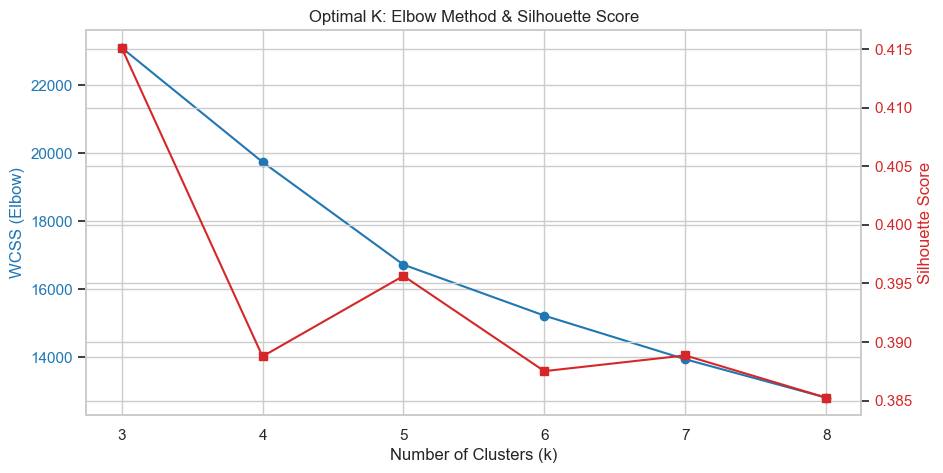

In [115]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Elbow)', color='tab:blue')
ax1.plot(k_range, wcss, 'o-', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(k_range, sil_scores, 's-', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Optimal K: Elbow Method & Silhouette Score')
plt.show()

Based on the plot above (usually where the Silhouette peaks or the Elbow bends), we pick our K. 
For this dataset, **K=5** is often a strong choice for business segmentation.

### 4.3 Conducting K means

In [116]:
optimal_k = 5 
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
dropped_data['Cluster'] = kmeans_final.fit_predict(X)

print(dropped_data['Cluster'].value_counts())

Cluster
2    2511
0    2399
3    1275
1    1140
4     717
Name: count, dtype: int64


### 4.4. Visualising the Clusters 

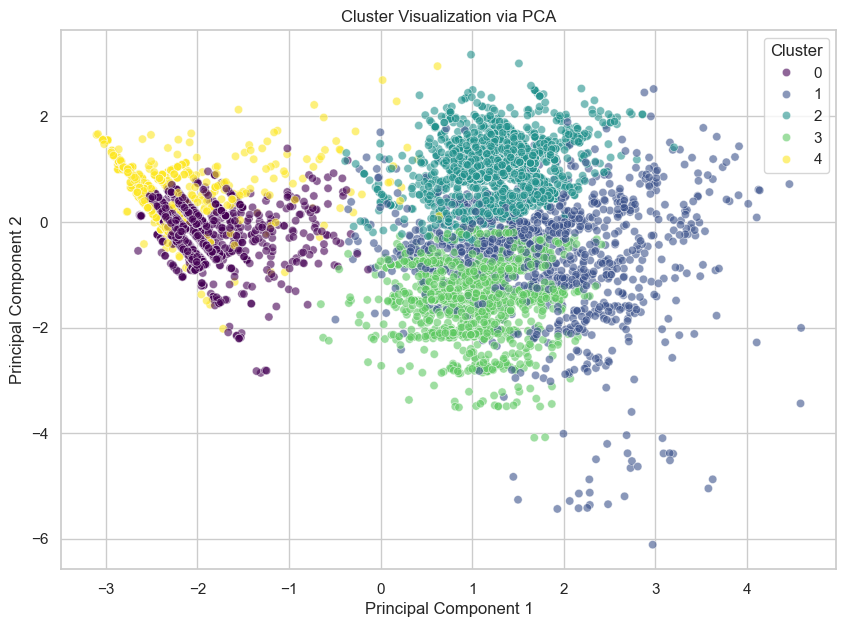

In [117]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dropped_data['Cluster'], palette='viridis', alpha=0.6)
plt.title('Cluster Visualization via PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

# I TRY HIERARCHICAL CLUSTERS BELOW. (dont run)

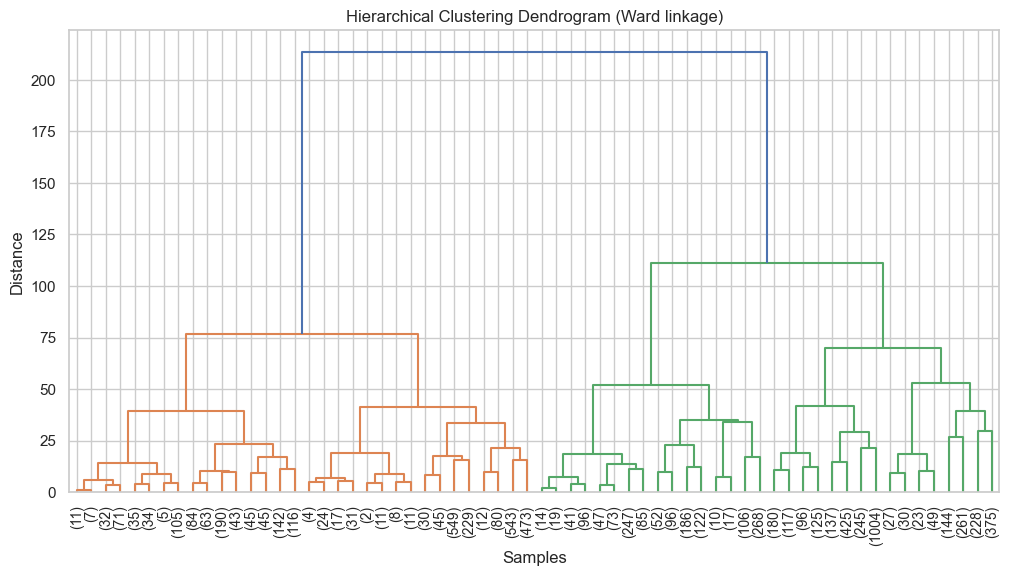

In [118]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score

# Use the same features as for K-Means
X_hc = X.copy()

# Compute linkage matrix using Ward's method (minimizes variance within clusters)
Z = linkage(X_hc, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(
    Z, 
    truncate_mode='level',  # show top levels
    p=5,                    # number of levels to display
    leaf_rotation=90, 
    leaf_font_size=10
)
plt.title('Hierarchical Clustering Dendrogram (Ward linkage)')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [119]:
# Assign cluster labels
hc_labels = fcluster(Z, t=5, criterion='maxclust')
dropped_data['HC_Cluster'] = hc_labels

# Inspect cluster sizes
print(dropped_data['HC_Cluster'].value_counts())

HC_Cluster
4    2329
2    2069
3    1479
5    1137
1    1028
Name: count, dtype: int64


In [120]:
hc_silhouette = silhouette_score(X_hc, hc_labels)
print(f"Hierarchical Clustering Silhouette Score: {hc_silhouette:.3f}")

Hierarchical Clustering Silhouette Score: 0.344


In [121]:
# Select features to summarize
summary_features = [
    'revenue_log_scaled', 'IT spend_log_scaled', 'log_total_devices',
    'employees_log_scaled', 'corp_family_log_scaled',
    'Is Global Ultimate Company', 'Is Domestic Ultimate Company',
    'SIC_2digit_encoded', 'Year_Range_encoded'
]

# Summary stats per cluster
cluster_summary = dropped_data.groupby('HC_Cluster')[summary_features].median().round(2)

# Count of companies per SIC 2-digit code in each cluster
sic_counts = dropped_data.groupby(['HC_Cluster', 'SIC_2digit_Description']).size().unstack(fill_value=0)

print("Cluster Median Features:")
display(cluster_summary)

print("\nTop SIC Codes per Cluster:")
display(sic_counts.apply(lambda x: x.sort_values(ascending=False).head(3), axis=1))


Cluster Median Features:


,revenue_log_scaled,IT spend_log_scaled,log_total_devices,employees_log_scaled,corp_family_log_scaled,Is Global Ultimate Company,Is Domestic Ultimate Company,SIC_2digit_encoded,Year_Range_encoded
HC_Cluster,,,,,,,,,
1,-1.24,-1.22,3.16,-1.05,1.47,0.0,0.0,0.06,8.0
2,-1.24,-1.22,3.16,-1.05,-0.44,0.0,0.0,0.04,9.0
3,0.77,0.76,3.43,-0.38,-0.78,1.0,1.0,0.05,7.0
4,0.82,0.86,3.85,0.92,-0.44,0.0,0.0,0.06,9.0
5,0.80,0.79,3.43,0.47,-0.10,0.0,0.0,0.05,7.0



Top SIC Codes per Cluster:


SIC_2digit_Description,"Accounting/auditing/bookkeeping , Architectural services , Business consulting services , Commercial nonphysical research , Commercial physical research , Engineering Services, Engineering services , Facilities support services , Management consulting services , Management services , Noncommercial research organization , Surveying services , Testing laboratory","Advertising agency , Advertising services , Building maintenance services , Business services , Business services, nec, nsk , Commercial art/graphic design , Computer related services , Computer systems design , Custom computer programming , Data processing/preparation , Disinfecting/pest services , Employment agency , Equipment rental/leasing , Heavy construction equipment rental , Help supply services , Outdoor advertising services , Photocopying services , Prepackaged software services , Secretarial/court reporting , Security systems services","Apartment building operator , Cemetery subdivider/developer , Dwelling operator , Nonresidential building operator , Railroad property lessor , Real estate agent/manager , Real property lessor , Subdivider/developer , Title abstract office","Metals service center , Whol appliances/tv/radio , Whol auto parts/supplies , Whol autos/motor vehicles , Whol brick/stone material , Whol coal/minerals/ores , Whol computers/peripherals , Whol construction materials , Whol construction/mining equipment , Whol durable goods , Whol electrical equipment , Whol electronic parts/equipment , Whol farm/garden machinery , Whol furniture , Whol hardware , Whol heat/air cond equipment/supplies , Whol homefurnishings , Whol industrial equipment , Whol industrial supplies , Whol jewelry/precious stones , Whol lumber/plywood/millwork , Whol medical/hospital equipment , Whol photo equipment/supplies , Whol plumbing equipment/supplies , Whol professional equipment , Whol scrap/waste material , Whol sporting/recreational goods , Whol toys/hobby goods , Whol used auto parts","Ret alcoholic beverages , Ret books , Ret drugs/sundries , Ret fuel dealer , Ret fuel oil dealer , Ret hobbies/toys/games , Ret jewelry , Ret liquefied petroleum gas , Ret luggage/leather goods , Ret mail-order house , Ret misc merchandise , Ret optical goods , Ret sewing supplies/fabrics , Ret sporting goods/bicycles , Ret stationery , Ret tobacco products"
HC_Cluster,,,,,
1,96.0,93.0,NaN,NaN,288.0
2,215.0,271.0,NaN,NaN,168.0
3,193.0,166.0,148.0,NaN,NaN
4,362.0,657.0,NaN,163.0,NaN
5,99.0,77.0,194.0,NaN,NaN


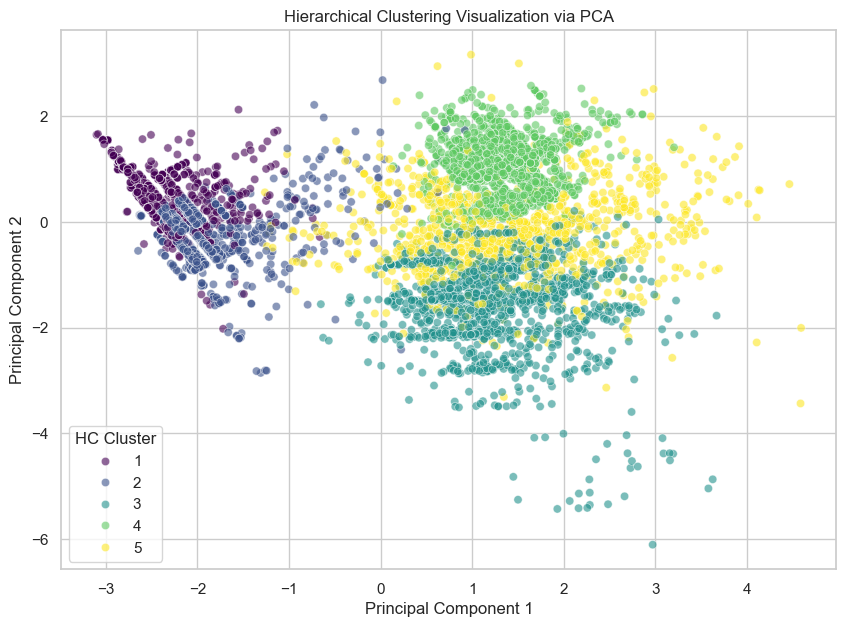

In [122]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_hc)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=dropped_data['HC_Cluster'], 
    palette='viridis', 
    alpha=0.6
)
plt.title('Hierarchical Clustering Visualization via PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='HC Cluster')
plt.show()

# I TRY LLM FRIENDLY CLUSTERS BELOW. (dont run)

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap.umap_ as umap
from sentence_transformers import SentenceTransformer

sns.set(style="whitegrid")

numeric_cols = [
    'revenue_log_scaled',
    'employees_log_scaled',
    'corp_family_log_scaled',
    'IT spend_log_scaled',
    'log_total_devices'
]

indicator_cols = [
    'total_devices_missing',
    'Is Global Ultimate Company',
    'Is Domestic Ultimate Company'
]

categorical_encoded_cols = [
    'Entity Type_Branch', 'Entity Type_Parent', 'Entity Type_Subsidiary',
    'Ownership Type_Other', 'Ownership Type_Private',
    'SIC_2digit_encoded',
    'Year_Range_encoded', 'Year_Range_missing'
]

features_for_clustering = numeric_cols + indicator_cols + categorical_encoded_cols
X_numeric = dropped_data[features_for_clustering].values

print(f"Numeric + categorical feature matrix shape: {X_numeric.shape}")

dropped_data['combined_text'] = (
    dropped_data['Company Description'].fillna('') + " " +
    dropped_data['SIC_2digit_Description'].fillna('')
)

model = SentenceTransformer('all-MiniLM-L6-v2')
print("Generating text embeddings...")
text_embeddings = model.encode(dropped_data['combined_text'].tolist(), show_progress_bar=True)
print(f"Text embeddings shape: {text_embeddings.shape}")


combined_features = np.hstack([X_numeric, text_embeddings])
print(f"Combined feature matrix shape: {combined_features.shape}")


pca = PCA(n_components=50, random_state=42)
pca_features = pca.fit_transform(combined_features)


Numeric + categorical feature matrix shape: (8042, 16)
Generating text embeddings...


Batches: 100%|██████████| 252/252 [00:33<00:00,  7.43it/s]


Text embeddings shape: (8042, 384)
Combined feature matrix shape: (8042, 400)


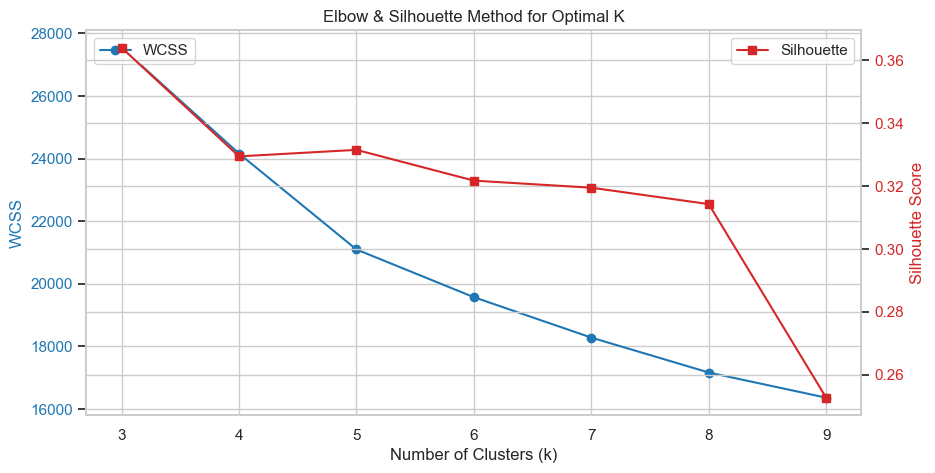

In [124]:
wcss = []
sil_scores = []
k_range = range(3, 10) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_features)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(pca_features, labels))

#plot elbow and silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(k_range, wcss, 'o-', color='tab:blue', label='WCSS')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 's-', color='tab:red', label='Silhouette')
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Elbow & Silhouette Method for Optimal K')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

In [125]:
optimal_k = 5 
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
dropped_data['Cluster'] = kmeans_final.fit_predict(pca_features)

sil_score_final = silhouette_score(pca_features, dropped_data['Cluster'])

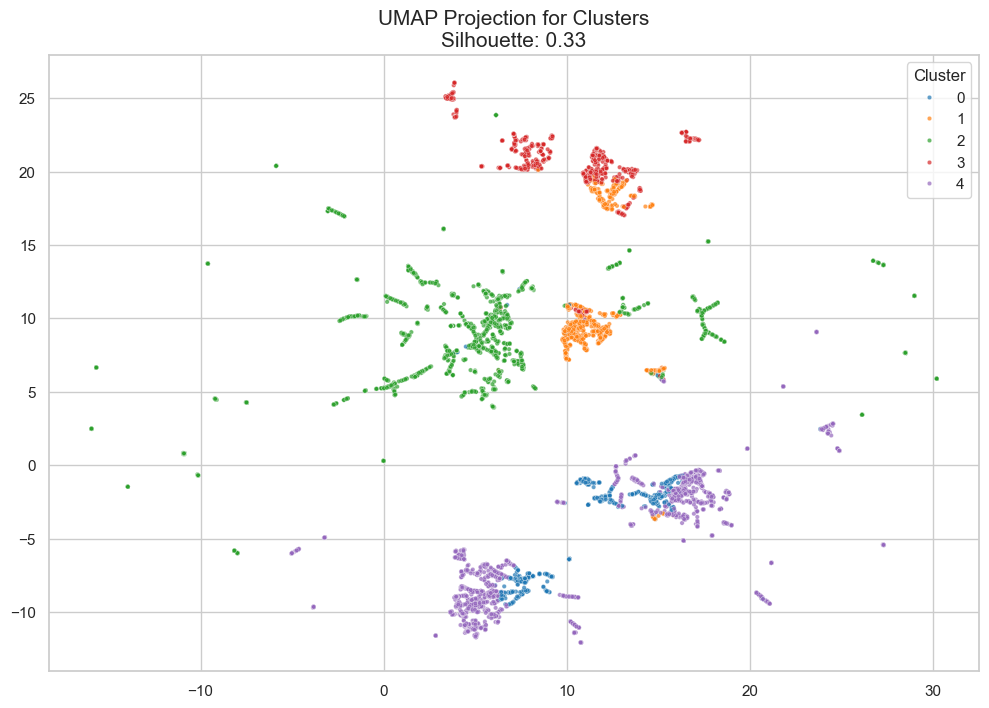

In [126]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(pca_features)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=embedding_2d[:, 0], y=embedding_2d[:, 1],
    hue=dropped_data['Cluster'], palette='tab10', s=10, alpha=0.7
)
plt.title(f'UMAP Projection for Clusters\nSilhouette: {sil_score_final:.2f}', fontsize=15)
plt.show()

In [127]:
for i in range(optimal_k):
    cluster_data = dropped_data[dropped_data['Cluster'] == i]
    avg_rev = cluster_data['Revenue (USD)'].mean() #idk if we want to use median here 
    avg_emp = cluster_data['Employees Single Site'].mean() #idk if we want to use median here 
    top_sic = cluster_data['SIC_2digit_Description'].value_counts().head(3).index.tolist()
    print(f"Cluster {i}: Size={len(cluster_data)} | Avg Revenue={avg_rev:,.0f} | Avg Employees={avg_emp:,.0f} | Top SICs: {top_sic}")

Cluster 0: Size=716 | Avg Revenue=34,317 | Avg Employees=8 | Top SICs: ['Ret alcoholic beverages                  , Ret books                                , Ret drugs/sundries                       , Ret fuel dealer                          , Ret fuel oil dealer                      , Ret hobbies/toys/games                   , Ret jewelry                              , Ret liquefied petroleum gas              , Ret luggage/leather goods                , Ret mail-order house                     , Ret misc merchandise                     , Ret optical goods                        , Ret sewing supplies/fabrics              , Ret sporting goods/bicycles              , Ret stationery                           , Ret tobacco products                     ', 'Freight transportation arrangement       , Motor freight fixed facility             , Packing/crating service                  , Railroad car rental                      , Tour operator                            , Travel agency         

**Cluster 4: $160, 2 employees → possibly outliers, tiny firms, or missing/incorrect data: Near Zero (Noise)?? I think cuz half of them has 0 revenue so maybe I was thinking we can js make an assumption at the top of our report n say these are like micro companies and then we dont do k means on them since its gna be unfair.**

**Cluster 0: $34k, 8 employees → small retail / local businesses: Very Low**

**Cluster 1: $10.9M, 92 employees → medium-sized companies, probably real estate / wholesale: Moderate (Labor Intensive/Large Scale)**

**Cluster 2: $3.5M, 27 employees → service companies / SMEs: Healthy (Standard Mid-Market)**

**Cluster 3: $9.3M, 5 employees → maybe small highly specialized consulting / niche companies: Extremely High (Asset Heavy or High-Value Niche)**

# TRYING WITHOUT THE COMPANIES W < 50000 REVENUE

In [39]:
# Create log transforms
dropped_data['employees_log'] = np.log1p(dropped_data['Employees Single Site'])
dropped_data['corp_family_log'] = np.log1p(dropped_data['Corporate Family Members'].fillna(0))

# Scale together
scaler = StandardScaler()
dropped_data[['employees_log_scaled', 'corp_family_log_scaled']] = scaler.fit_transform(
    dropped_data[['employees_log', 'corp_family_log']]
)

In [40]:
micro_threshold = 50000  # revenue < $50k considered micro businesses

micro_companies = dropped_data[dropped_data['Revenue (USD)'] < micro_threshold].copy()
active_companies = dropped_data[dropped_data['Revenue (USD)'] >= micro_threshold].copy()

print(f"Micro Companies (<${micro_threshold}): {len(micro_companies)}")
print(f"Active Companies (≥${micro_threshold}): {len(active_companies)}")

Micro Companies (<$50000): 3298
Active Companies (≥$50000): 4744


In [41]:
numeric_cols = [
    'revenue_log_scaled',
    'employees_log_scaled',
    'corp_family_log_scaled',
    'IT spend_log_scaled',
    'log_total_devices'
]

indicator_cols = [
    'total_devices_missing',
    'Is Global Ultimate Company',
    'Is Domestic Ultimate Company'
]

# categorical_encoded_cols = [
#     'Entity Type_Branch', 'Entity Type_Parent', 'Entity Type_Subsidiary',
#     'Ownership Type_Other', 'Ownership Type_Private',
#     'SIC_2digit_encoded',
#     'Year_Range_encoded', 'Year_Range_missing'
# ]
#I didnt include categorical columns for this clustering to keep it simpler for LLMs to interpret^

features_for_clustering = numeric_cols + indicator_cols 

X_active = active_companies[features_for_clustering].values

In [42]:
active_companies['combined_text'] = (
    active_companies['Company Description'].fillna('') + " " +
    active_companies['SIC_2digit_Description'].fillna('')
)

from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Generating text embeddings for active companies...")
text_embeddings = model.encode(active_companies['combined_text'].tolist(), show_progress_bar=True)

combined_features = np.hstack([X_active, text_embeddings])
print(f"Combined feature matrix shape (active companies only): {combined_features.shape}")

Generating text embeddings for active companies...


Batches: 100%|██████████| 149/149 [00:18<00:00,  7.92it/s]

Combined feature matrix shape (active companies only): (4744, 392)


In [43]:
from sklearn.decomposition import PCA
pca = PCA(n_components=50, random_state=42)
pca_features = pca.fit_transform(combined_features)

In [44]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

wcss = []
sil_scores = []
k_range = range(3, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_features)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(pca_features, labels))

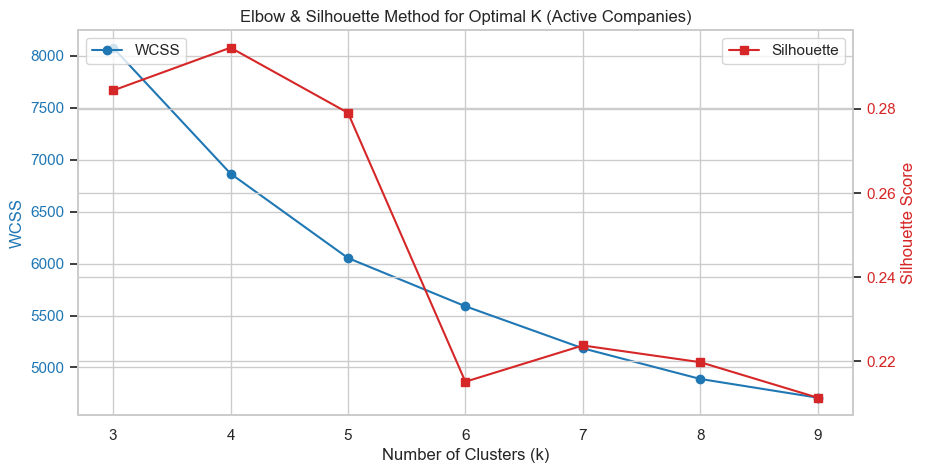

In [45]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(k_range, wcss, 'o-', color='tab:blue', label='WCSS')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 's-', color='tab:red', label='Silhouette')
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Elbow & Silhouette Method for Optimal K (Active Companies)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

From the result above, we can see that the optimal k is 4 since it shows a clear elbow in the WCSS curve (where the rate of decrease starts to level off) and the highest silhouette score among the tested values, indicating the best balance between cluster compactness and separation.

In [46]:
optimal_k = 4 
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
active_companies['Cluster'] = kmeans_final.fit_predict(pca_features)
print(f"Active Companies Cluster Sizes:\n{active_companies['Cluster'].value_counts()}")

micro_companies['Cluster'] = 'Micro'
final_clusters = pd.concat([active_companies, micro_companies], axis=0)

Active Companies Cluster Sizes:
Cluster
0    2490
1    1254
2     721
3     279
Name: count, dtype: int64


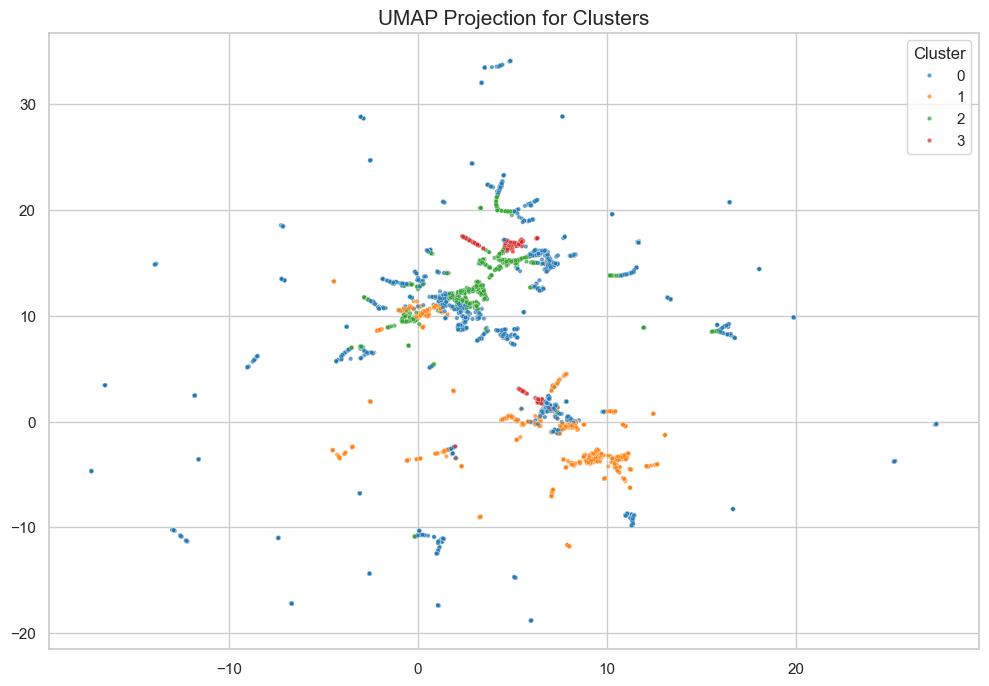

In [49]:
import umap.umap_ as umap
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(pca_features)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=embedding_2d[:, 0], y=embedding_2d[:, 1],
    hue=active_companies['Cluster'], palette='tab10', s=10, alpha=0.7
)
plt.title('UMAP Projection for Clusters', fontsize=15)
plt.show()

The UMAP visualization shows four moderately well-defined clusters with partial overlap, consistent with the silhouette score of 0.29. This suggests meaningful but non-exclusive segmentation among active companies, which is expected given the complex and overlapping nature of real-world corporate attributes.

In [50]:
for label in final_clusters['Cluster'].unique():
    cluster_data = final_clusters[final_clusters['Cluster'] == label]
    avg_rev = cluster_data['Revenue (USD)'].mean()
    avg_emp = cluster_data['Employees Single Site'].mean()
    top_sic = cluster_data['SIC_2digit_Description'].value_counts().head(3).index.tolist()
    print(f"Cluster {label}: Size={len(cluster_data)} | Avg Revenue={avg_rev:,.0f} | Avg Employees={avg_emp:,.0f} | Top SICs: {top_sic}")

Cluster 0: Size=2490 | Avg Revenue=3,464,164 | Avg Employees=26 | Top SICs: ['Advertising agency                       , Advertising services                     , Building maintenance services            , Business services                        , Business services, nec, nsk              , Commercial art/graphic design            , Computer related services                , Computer systems design                  , Custom computer programming              , Data processing/preparation              , Disinfecting/pest services               , Employment agency                        , Equipment rental/leasing                 , Heavy construction equipment rental      , Help supply services                     , Outdoor advertising services             , Photocopying services                    , Prepackaged software services            , Secretarial/court reporting              , Security systems services                ', 'Accounting/auditing/bookkeeping          , Architectural ser

In [51]:
CLUSTER_METADATA = {
    0: {
        "name": "Small Service Providers",
        "summary": "Established small to mid-sized service firms relying on human expertise.",
        "key_traits": [
            "Service-driven revenue",
            "Moderate team sizes",
            "Limited automation",
            "Regional or niche focus"
        ],
        "typical_industries": [
            "Business services",
            "IT & software services",
            "Advertising & creative",
            "Facilities support",
            "Real estate management"
        ]
    },
    1: {
        "name": "Lean & IP-Driven Firms",
        "summary": "High-revenue companies operating with extremely small teams.",
        "key_traits": [
            "Very high revenue per employee",
            "Owner-led or partner-based",
            "IP or expertise-driven"
        ],
        "typical_industries": [
            "Consulting",
            "Engineering",
            "Research & advisory",
            "Licensing-based services"
        ]
    },
    2: {
        "name": "Scaling Professional Firms",
        "summary": "Growth-stage service companies expanding teams and market reach.",
        "key_traits": [
            "Growing headcount",
            "Increasing operational structure",
            "Balanced revenue-to-employee ratio"
        ],
        "typical_industries": [
            "IT services",
            "Consulting",
            "Agencies",
            "Professional services"
        ]
    },
    3: {
        "name": "Industrial & Infrastructure Enterprises",
        "summary": "Large, asset-heavy firms operating in manufacturing and utilities.",
        "key_traits": [
            "Capital-intensive operations",
            "Large workforce",
            "Stable but complex operations"
        ],
        "typical_industries": [
            "Manufacturing",
            "Utilities",
            "Infrastructure services",
            "Industrial supply"
        ]
    },
    "micro": {
        "name": "Micro & Low-Activity Entities",
        "summary": "Very small or low-activity firms with limited economic footprint.",
        "key_traits": [
            "Minimal revenue",
            "Small teams",
            "Often early-stage or dormant"
        ],
        "typical_industries": [
            "Retail",
            "Small services",
            "Sole proprietorships"
        ]
    }
}


In [52]:
final_clusters

,DUNS Number,Company Sites,City,State,Country,Employees Single Site,Employees Total,Revenue (USD),SIC Code,SIC Description,...,Ownership Type_Private,SIC_2digit_encoded,Year_Range_encoded,Year_Range_missing,employees_log,corp_family_log,employees_log_scaled,corp_family_log_scaled,combined_text,Cluster
1,547756179,"Beijing Kaishi Lide Commerce And Trade Co., Lt...",Beijing,Beijing,China,20.0,20,311166,5651,Ret family clothing,...,True,0.001402,7.0,0,3.044522,1.098612,0.811096,-0.782714,"Ret family clothing , Re...",0
2,728834216,Keshan Shengren Potato Industry Processing Co....,Qiqihar,Heilongjiang,China,89.0,89,2414036,2037,Mfg frozen fruits/vegetables,...,True,0.011800,8.0,0,4.499810,2.302585,1.700731,-0.186858,Keshan Shengren Potato Industry Processing Co....,0
3,728791839,Zuoquan County Yuanfeng Agriculture Technology...,Jinzhong,Shanxi,China,0.0,0,306060,191,General crop farm,...,True,0.005374,8.0,0,0.000000,1.386294,-1.050057,-0.640338,General crop farm,1
4,728889244,Zuoquan County Tianxin Real Estate Development...,Jinzhong,Shanxi,China,2.0,2,1167456,6552,Subdivider/developer,...,True,0.060521,8.0,0,1.098612,1.098612,-0.378462,-0.782714,"Apartment building operator , Ce...",1
5,547827642,Zuoquan County People's Hospital ...,Jinzhong,Shanxi,China,0.0,0,17105280,8062,General hospital,...,False,0.011333,8.0,1,0.000000,1.098612,-1.050057,-0.782714,"General hospital , He...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8554,728769788,"Xi'an Yikang Medicine Franchise Co., Ltd. Lint...",Xi'an,Shaanxi,China,0.0,0,0,5999,Ret misc merchandise,...,True,0.068700,8.0,0,0.000000,7.303170,-1.050057,2.287973,NaN,Micro
8555,728788434,"Xi'an Yikang Medicine Franchise Co., Ltd. Hanz...",Hanzhong,Shaanxi,China,0.0,0,0,5999,Ret misc merchandise,...,True,0.068700,8.0,0,0.000000,7.303170,-1.050057,2.287973,NaN,Micro
8556,728777035,"Xi'an Yikang Medicine Franchise Co., Ltd. Zaoy...",Xi'an,Shaanxi,China,0.0,0,0,5047,Whol medical/hospital equipment,...,True,0.055614,8.0,0,0.000000,7.303170,-1.050057,2.287973,NaN,Micro
8557,728775522,"Xi'An Yikang Medicine Franchise Co., Ltd. Tech...",Xi'an,Shaanxi,China,0.0,0,0,5999,Ret misc merchandise,...,True,0.068700,8.0,0,0.000000,7.303170,-1.050057,2.287973,NaN,Micro


In [56]:
#save final clustered data to a pkl file
final_clusters.to_pickle('../data/clustered_companies.pkl')